# **Script Data Collection**

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google_play_scraper import Sort, reviews
from datetime import datetime

In [ ]:
# Mengambil ulasan Tiket.com dengan jumlah 50.000
result, continuation_token = reviews(
    app_id='com.tiket.gits',  # ID aplikasi Tiket.com
    lang='id',  # Bahasa Indonesia
    country='id',  # Negara Indonesia
    sort=Sort.MOST_RELEVANT,  # Ulasan paling relevan
    count=50000  # Jumlah ulasan yang diambil
)

In [ ]:
# Mengonversi hasil menjadi DataFrame
data = pd.DataFrame(result)

In [ ]:
# Filter hanya ulasan tahun 2024
data['datetime'] = pd.to_datetime(data['at'])
filtered_data = data[data['datetime'].dt.year == 2024]

In [ ]:
# Pilih kolom yang dibutuhkan saja
final_df = filtered_data[['userName', 'score', 'at', 'content']]

In [ ]:
# Menampilkan preview 10 baris pertama dari data yang telah difilter
print("Contoh 10 Baris Pertama Data yang Telah Difilter:")
print(final_df.head(10))  # Menampilkan 10 baris pertama

Contoh 10 Baris Pertama Data yang Telah Difilter:
           userName  score                  at  \
0   Pengguna Google      1 2024-12-16 04:24:39   
1   Pengguna Google      1 2024-12-31 06:36:12   
2   Pengguna Google      4 2024-12-20 14:55:26   
3   Pengguna Google      5 2024-12-27 03:20:48   
5   Pengguna Google      2 2024-12-23 16:27:53   
6   Pengguna Google      1 2024-12-22 02:44:55   
7   Pengguna Google      1 2024-10-18 06:31:45   
8   Pengguna Google      1 2024-12-18 11:25:48   
10  Pengguna Google      3 2024-12-07 05:33:21   
11  Pengguna Google      1 2024-12-08 04:22:40   

                                              content  
0   Aplikasi ini syaa lihat sangat mundur dibandin...  
1   Ribet banget, tiap kluar 1 fitur/pilihan dan s...  
2   Tolong perlindungan ekstra di setiap pemesanan...  
3   Sangat bagus Utk lebih bagus nya lagi ada kera...  
5   Resepsionis cukup ramah, pelayanan dan kebersi...  
6   Ini aplikasi apaan dah asal mau di payment, mi...  
7   Gak

In [ ]:
# Menampilkan informasi umum data
print("\nInformasi Data:")
print(final_df.info())  # Struktur data


Informasi Data:
<class 'pandas.core.frame.DataFrame'>
Index: 2512 entries, 0 to 40458
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   userName  2512 non-null   object        
 1   score     2512 non-null   int64         
 2   at        2512 non-null   datetime64[ns]
 3   content   2512 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 98.1+ KB
None


In [ ]:
print("\nStatistik Deskriptif:")
print(final_df.describe(include='all'))  # Statistik kolom


Statistik Deskriptif:
               userName        score                             at content
count              2512  2512.000000                           2512    2512
unique             1457          NaN                            NaN    2005
top     Pengguna Google          NaN                            NaN  mantap
freq               1052          NaN                            NaN      69
mean                NaN     3.750796  2024-06-24 02:35:55.395700736     NaN
min                 NaN     1.000000            2024-01-01 05:37:51     NaN
25%                 NaN     1.000000  2024-03-22 11:49:41.750000128     NaN
50%                 NaN     5.000000            2024-06-18 05:33:58     NaN
75%                 NaN     5.000000  2024-09-21 14:20:36.750000128     NaN
max                 NaN     5.000000            2024-12-31 20:13:27     NaN
std                 NaN     1.755460                            NaN     NaN


In [ ]:
# Simpan hasil ke file CSV
final_df.to_csv('tiket_reviews_2024_final.csv', index=False)

In [ ]:
print("\nData scraping selesai! Hasil disimpan di 'tiket_reviews_2024_final.csv'")


Data scraping selesai! Hasil disimpan di 'tiket_reviews_2024_final.csv'


# **Script Data Preprocessing**

In [ ]:
import pandas as pd
import re

In [ ]:
# Membaca data hasil scraping sebelumnya
df = pd.read_csv('tiket_reviews_2024_final.csv')

In [ ]:
# 1. Menghapus Kolom yang Tidak Diperlukan (jika ada tambahan kolom sebelumnya)
# Kolom yang digunakan: 'userName', 'score', 'at', 'content'
df = df[['userName', 'score', 'at', 'content']]

In [ ]:
# 2. Menghapus Data Duplikat
df = df.drop_duplicates()

In [ ]:
# 3. Menghapus Nilai Kosong (Missing Values)
df = df.dropna()

In [ ]:
# 4. Membersihkan Teks (Menghapus URL dan simbol khusus)
def clean_text(text):
    # Menghapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Menghapus karakter khusus dan angka
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()  # Mengubah teks menjadi huruf kecil

df['content'] = df['content'].apply(clean_text)

In [ ]:
# 5. Menyimpan hasil preprocessing ke CSV baru
df.to_csv('tiket_reviews_2024_preprocessed.csv', index=False)

In [ ]:
# 6. Menampilkan Informasi Data Setelah Preprocessing
print("\nInformasi Data Setelah Preprocessing:")
print(df.info())


Informasi Data Setelah Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  2512 non-null   object
 1   score     2512 non-null   int64 
 2   at        2512 non-null   object
 3   content   2512 non-null   object
dtypes: int64(1), object(3)
memory usage: 78.6+ KB
None


In [ ]:
print("\nContoh 5 Baris Data yang Sudah Diproses:")
print(df.head(5))


Contoh 5 Baris Data yang Sudah Diproses:
          userName  score                   at  \
0  Pengguna Google      1  2024-12-16 04:24:39   
1  Pengguna Google      1  2024-12-31 06:36:12   
2  Pengguna Google      4  2024-12-20 14:55:26   
3  Pengguna Google      5  2024-12-27 03:20:48   
4  Pengguna Google      2  2024-12-23 16:27:53   

                                             content  
0  aplikasi ini syaa lihat sangat mundur dibandin...  
1  ribet banget tiap kluar fiturpilihan dan sejen...  
2  tolong perlindungan ekstra di setiap pemesanan...  
3  sangat bagus utk lebih bagus nya lagi ada kera...  
4  resepsionis cukup ramah pelayanan dan kebersih...  


In [ ]:
print("\nPreprocessing selesai! File disimpan dengan nama 'tiket_reviews_2024_preprocessed.csv'")


Preprocessing selesai! File disimpan dengan nama 'tiket_reviews_2024_preprocessed.csv'


# **Script Analisis Sentimen Secara General**

In [ ]:
# Import library utama
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cek apakah GPU tersedia dan pindahkan proses ke GPU jika ada
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Menggunakan device:", device)

Menggunakan device: cuda


In [ ]:
# Muat data preprocessed
df = pd.read_csv('tiket_reviews_2024_preprocessed.csv')

# Validasi data
print("Jumlah data sebelum preprocessing:", len(df))
df = df.dropna(subset=['content', 'score'])  # Hapus nilai kosong
df['content'] = df['content'].astype(str)   # Pastikan semua teks dalam bentuk string
df['score'] = df['score'].astype(int)       # Pastikan skor dalam bentuk integer
df = df[df['content'].str.strip() != '']    # Hapus teks kosong
print("Jumlah data setelah preprocessing:", len(df))

Jumlah data sebelum preprocessing: 2512
Jumlah data setelah preprocessing: 2490


In [ ]:
# Membuat label sentimen (0 = Positif, 1 = Netral, 2 = Negatif)
labels = []
for score in df['score']:
    if score >= 4:
        labels.append(0)  # Positif
    elif score == 3:
        labels.append(1)  # Netral
    else:
        labels.append(2)  # Negatif

# Konversi labels ke tensor dan pindahkan ke GPU
labels = torch.tensor(labels).to(device)
print("Jumlah labels:", len(labels))  # Harus sama dengan jumlah data

Jumlah labels: 2490


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load tokenizer dan model baru yang sudah di-finetuned
tokenizer = AutoTokenizer.from_pretrained("ayameRushia/indobert-base-uncased-finetuned-indonlu-smsa")
model = AutoModelForSequenceClassification.from_pretrained("ayameRushia/indobert-base-uncased-finetuned-indonlu-smsa", num_labels=3)

# Pindahkan model ke GPU
model.to(device)
print("Model dan tokenizer berhasil dimuat!")

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/234k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/736k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/924 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Model dan tokenizer berhasil dimuat!


In [ ]:
# Tokenisasi teks
tokens = tokenizer.batch_encode_plus(
    df['content'].tolist(),
    max_length=128,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

# Pindahkan token ke GPU
input_ids = tokens['input_ids'].to(device)
attention_mask = tokens['attention_mask'].to(device)

print("\nTokenisasi Berhasil!")


Tokenisasi Berhasil!


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Buat Dataset dan DataLoader
dataset = TensorDataset(input_ids, attention_mask, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

print("DataLoader siap digunakan!")

DataLoader siap digunakan!


In [ ]:
# Prediksi Sentimen
model.eval()  # Model dalam mode evaluasi
predictions = []

with torch.no_grad():
    for batch in dataloader:
        input_ids, attention_mask, batch_labels = batch
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().numpy())  # Pindahkan hasil prediksi ke CPU

print("Prediksi selesai!")

Prediksi selesai!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi Model
labels = labels.cpu()  # Pindahkan labels ke CPU untuk evaluasi
predictions = torch.tensor(predictions).cpu()

print("\nEvaluasi Model:")
print("Accuracy Score:", accuracy_score(labels, predictions))
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=["Positif", "Netral", "Negatif"]))


Evaluasi Model:
Accuracy Score: 0.8369477911646587

Classification Report:
              precision    recall  f1-score   support

     Positif       0.97      0.88      0.92      1673
      Netral       0.08      0.23      0.11        84
     Negatif       0.82      0.81      0.82       733

    accuracy                           0.84      2490
   macro avg       0.62      0.64      0.62      2490
weighted avg       0.90      0.84      0.86      2490




Confusion Matrix:
[[1469  128   76]
 [  14   19   51]
 [  35  102  596]]


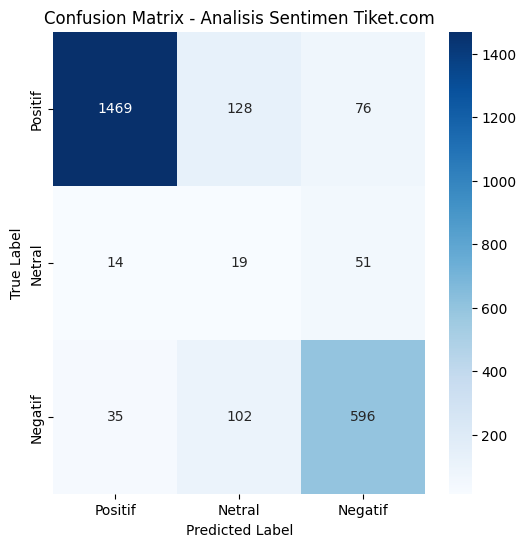

In [ ]:
# Confusion Matrix
cm = confusion_matrix(labels, predictions)
print("\nConfusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Positif", "Netral", "Negatif"], yticklabels=["Positif", "Netral", "Negatif"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Analisis Sentimen Tiket.com')
plt.show()


Jumlah Ulasan Berdasarkan Sentimen:
sentiment_label
Positif    1518
Negatif     723
Netral      249
Name: count, dtype: int64

Persentase Ulasan Berdasarkan Sentimen:
sentiment_label
Positif    60.963855
Negatif    29.036145
Netral     10.000000
Name: count, dtype: float64


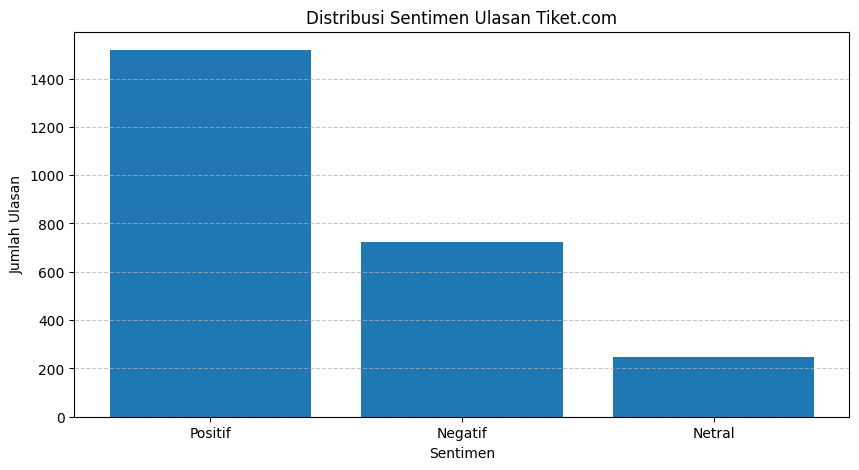

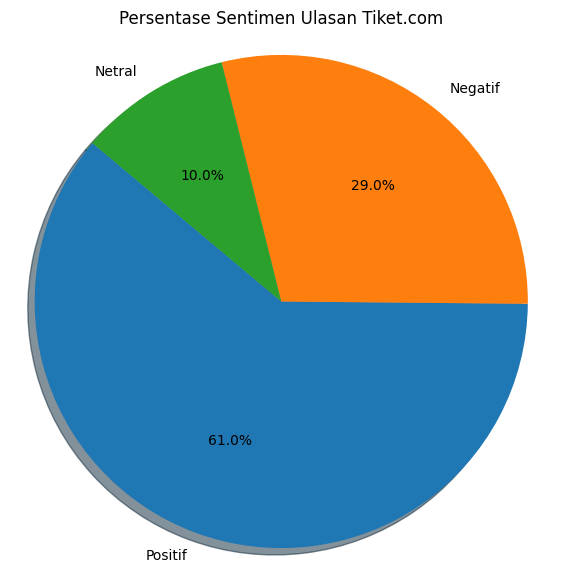

In [ ]:
# Distribusi Sentimen
df['sentiment_label'] = ['Positif' if p == 0 else 'Netral' if p == 1 else 'Negatif' for p in predictions]

# Hitung jumlah dan persentase sentimen
sentiment_count = df['sentiment_label'].value_counts()
sentiment_percentage = (sentiment_count / sentiment_count.sum()) * 100

print("\nJumlah Ulasan Berdasarkan Sentimen:")
print(sentiment_count)
print("\nPersentase Ulasan Berdasarkan Sentimen:")
print(sentiment_percentage)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title('Distribusi Sentimen Ulasan Tiket.com')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualisasi Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(sentiment_count, labels=sentiment_count.index, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title('Persentase Sentimen Ulasan Tiket.com')
plt.axis('equal')
plt.show()

In [ ]:
# Tambahkan prediksi ke dalam dataframe
df['predicted_label'] = predictions.cpu().numpy()  # Konversi prediksi ke numpy array

# Ubah label angka ke kategori (0: Positif, 1: Netral, 2: Negatif)
df['predicted_sentiment'] = df['predicted_label'].map({0: 'Positif', 1: 'Netral', 2: 'Negatif'})

# Simpan hasil ke CSV dengan nama yang sesuai
df.to_csv('hasil_prediksi_sentimen_tiketcom.csv', index=False)

print("Hasil prediksi telah disimpan dalam 'hasil_prediksi_sentimen_tiketcom.csv'")

Hasil prediksi telah disimpan dalam 'hasil_prediksi_sentimen_tiketcom.csv'
